In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv('/content/engineered_churn_data.csv')

print("Shape:", df.shape)
df.head()

Shape: (7043, 27)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,CLV,AvgMonthlySpend,ServiceCount,ContractRiskScore,ElectronicCheckFlag,TenureGroup,HighSpendFlag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,29.85,0,29.85,29.850000,1,3,1,New,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,0,1936.30,55.573529,3,2,0,Mature,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,1,107.70,54.075000,3,3,0,New,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,42.30,1840.75,0,1903.50,40.905556,3,2,0,Mature,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,1,141.40,75.825000,1,3,1,New,1


In [2]:
# Separate categorical and numerical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Categorical Columns:", cat_cols)

# Apply Label Encoding
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ Encoding Done!")
print(df.dtypes)

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
✅ Encoding Done!
gender                   int64
SeniorCitizen            int64
Partner                  int64
Dependents               int64
tenure                   int64
PhoneService             int64
MultipleLines            int64
InternetService          int64
OnlineSecurity           int64
OnlineBackup             int64
DeviceProtection         int64
TechSupport              int64
StreamingTV              int64
StreamingMovies          int64
Contract                 int64
PaperlessBilling         int64
PaymentMethod            int64
MonthlyCharges         float64
TotalCharges           float64
Churn                    int64
CLV                    float64
AvgMonthlySpend        float64
ServiceCount             

In [3]:
# Target column
target = 'Churn'

# Features
X = df.drop(columns=[target])
y = df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nChurn Distribution:")
print(y.value_counts())

Features Shape: (7043, 26)
Target Shape: (7043,)

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [4]:
# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {0: 5174, 1: 1869}
After SMOTE : {0: 5174, 1: 5174}


In [5]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("Train Size:", X_train.shape)
print("Test Size :", X_test.shape)

Train Size: (8278, 26)
Test Size : (2070, 26)


In [6]:
# Scale numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Feature Scaling Done!")

✅ Feature Scaling Done!


In [7]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM'                : SVC(probability=True, random_state=42)
}

# Train and store results
results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_proba)
    }

    print(f"✅ {name} Done!")


🔄 Training Logistic Regression...
✅ Logistic Regression Done!

🔄 Training Random Forest...
✅ Random Forest Done!

🔄 Training XGBoost...
✅ XGBoost Done!

🔄 Training SVM...
✅ SVM Done!



📊 Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8198     0.7950  0.8618    0.8271   0.9121
Random Forest          0.8609     0.8474  0.8802    0.8635   0.9363
XGBoost                0.8391     0.8343  0.8464    0.8403   0.9296
SVM                    0.8377     0.8288  0.8512    0.8398   0.9132


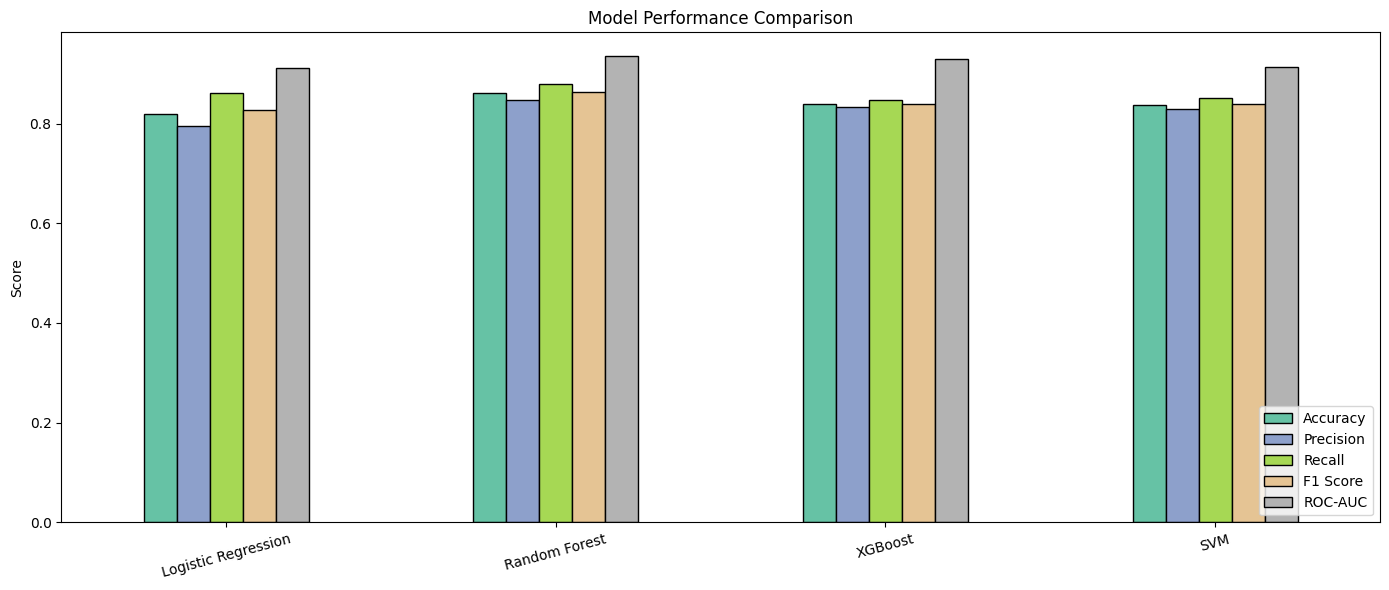

In [8]:
# Build comparison dataframe
comparison = pd.DataFrame({
    name: {
        'Accuracy' : v['accuracy'],
        'Precision': v['precision'],
        'Recall'   : v['recall'],
        'F1 Score' : v['f1'],
        'ROC-AUC'  : v['roc_auc']
    }
    for name, v in results.items()
}).T.round(4)

print("\n📊 Model Comparison:")
print(comparison)

# Visualize
comparison.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

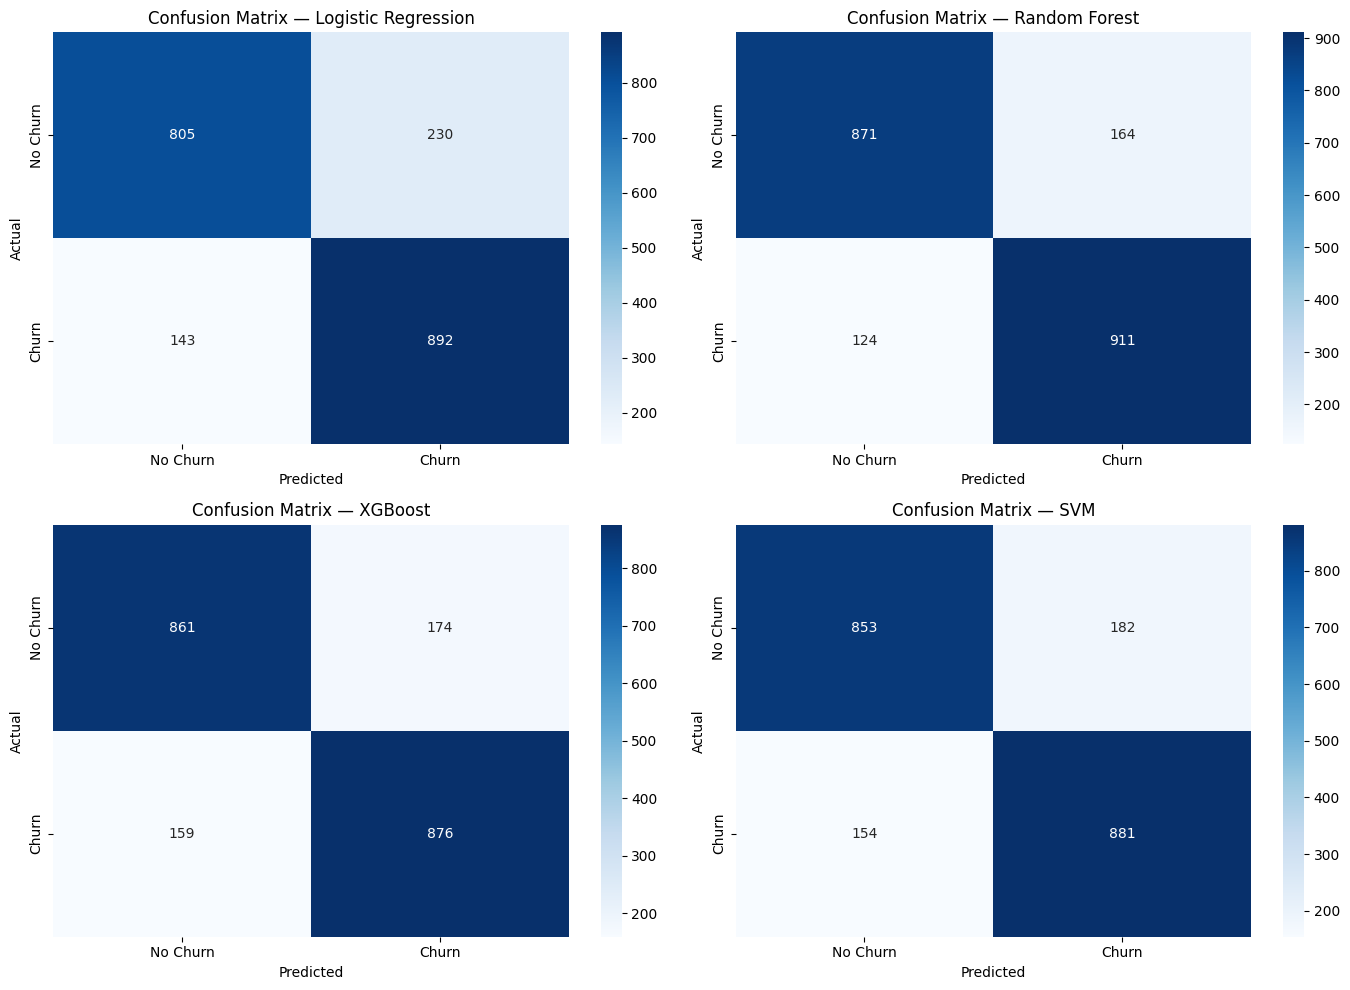

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, v) in enumerate(results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(f'Confusion Matrix — {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

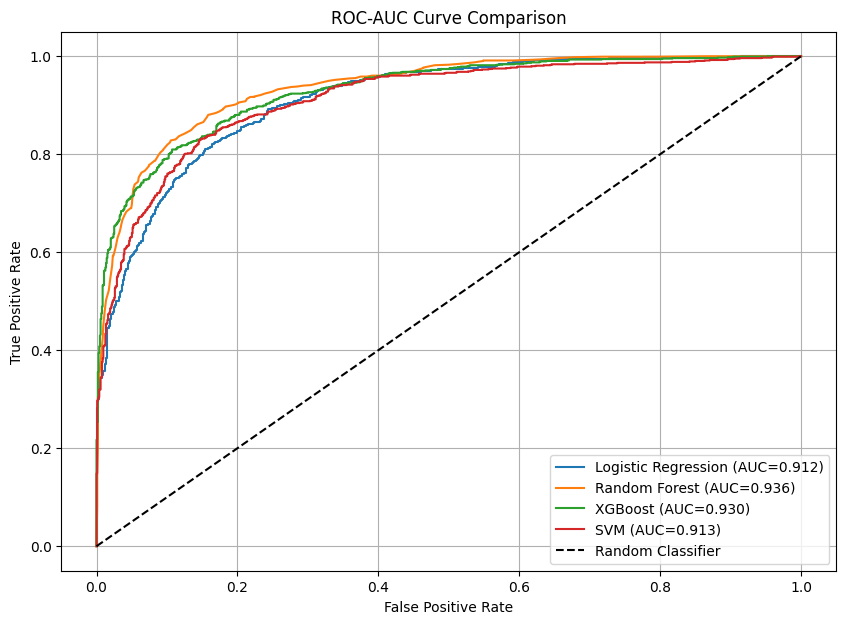

In [10]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={v['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [11]:
# Pick best model based on F1 Score
best_model_name = comparison['F1 Score'].idxmax()
best_model      = results[best_model_name]['model']

print("=" * 45)
print(f"  🏆 Best Model : {best_model_name}")
print(f"  ✅ F1 Score   : {comparison.loc[best_model_name, 'F1 Score']:.4f}")
print(f"  ✅ ROC-AUC    : {comparison.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"  ✅ Accuracy   : {comparison.loc[best_model_name, 'Accuracy']:.4f}")
print("=" * 45)

  🏆 Best Model : Random Forest
  ✅ F1 Score   : 0.8635
  ✅ ROC-AUC    : 0.9363
  ✅ Accuracy   : 0.8609


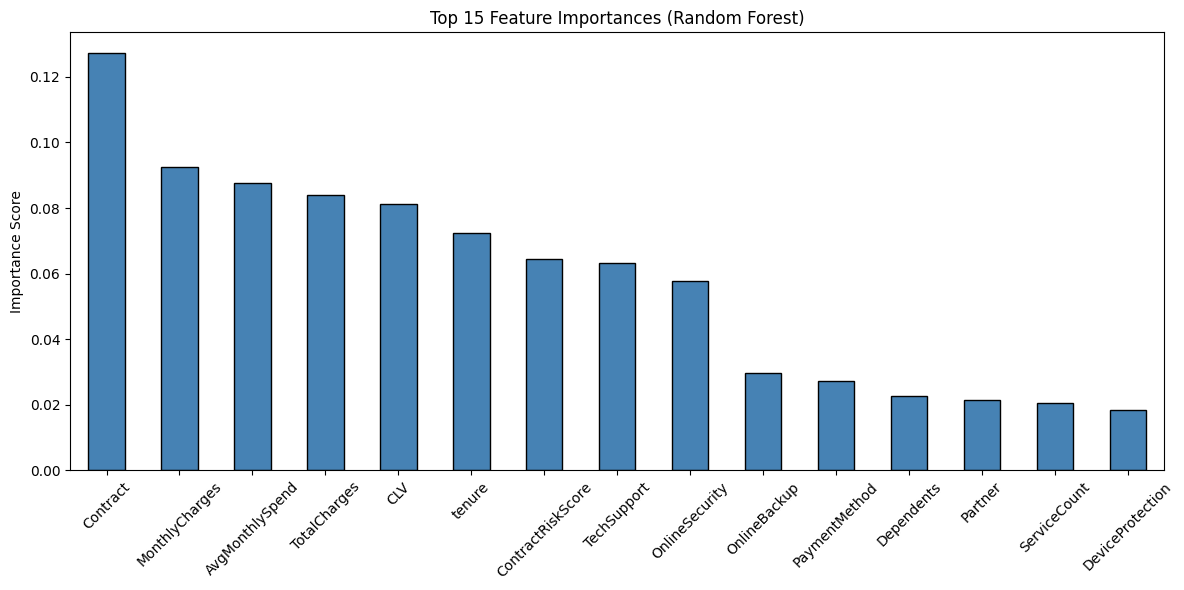

In [12]:
# Get feature importances from Random Forest
rf_model = results['Random Forest']['model']

# Re-fit on original feature names
feature_names = df.drop(columns=['Churn']).columns

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 6))
importances[:15].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
import joblib

# Save best model and scaler
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"✅ Best Model saved  : best_churn_model.pkl")
print(f"✅ Scaler saved      : scaler.pkl")
print(f"✅ Best Model        : {best_model_name}")

✅ Best Model saved  : best_churn_model.pkl
✅ Scaler saved      : scaler.pkl
✅ Best Model        : Random Forest
